In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

%matplotlib inline

In [19]:
# (1a) In Part 1, we will be exploring the mushroom.csv database. First, let us load the database and look at
# at the first few rows.
df = pd.read_csv("mushrooms.csv")
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,NaN,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,NaN,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,NaN,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,NaN,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,NaN,o,e,n,a,g


<Axes: >

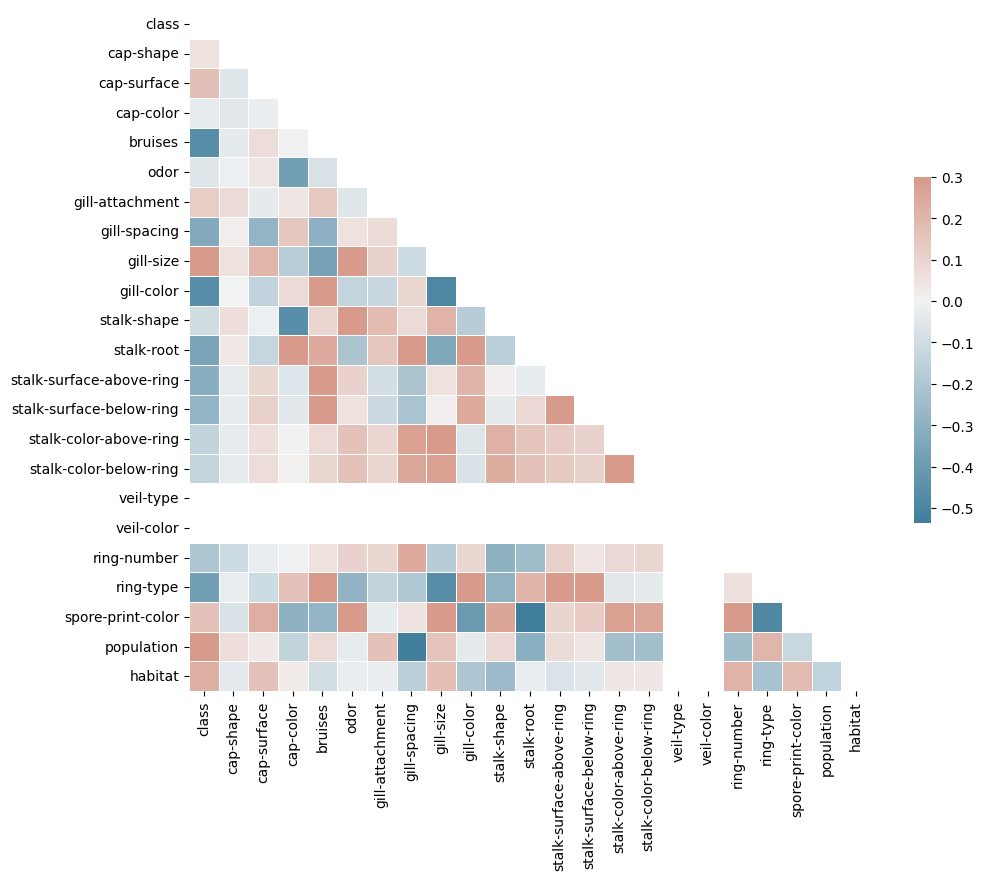

In [20]:
# (1b) Compute the correlation matrix and visualize it as a heatmap.
# https://seaborn.pydata.org/examples/many_pairwise_correlations.html

Encoder_Data = LabelEncoder()
for col in df.columns: df[col] = Encoder_Data.fit_transform(df[col])

# Compute the correlation matrix
corr = df.corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})


/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:453: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=figsize)


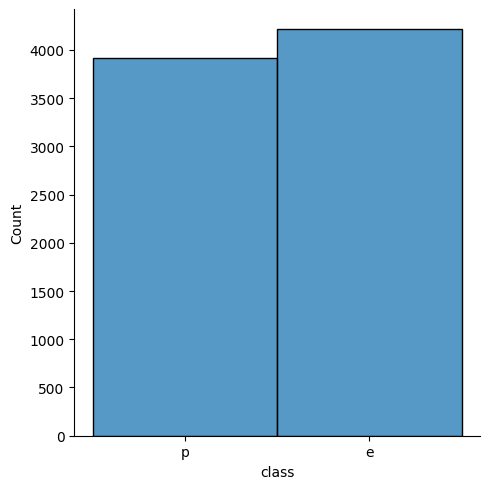

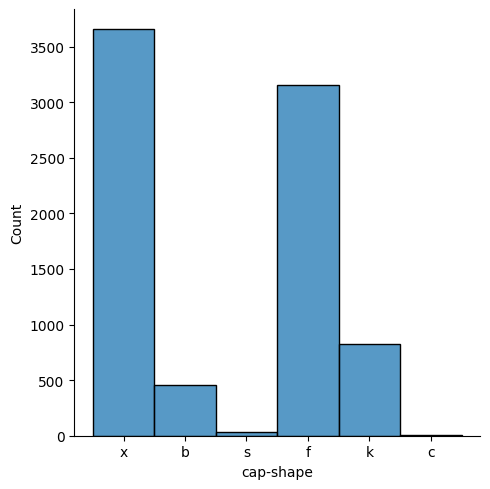

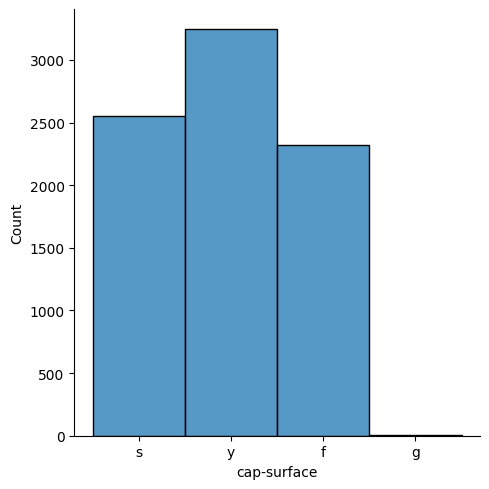

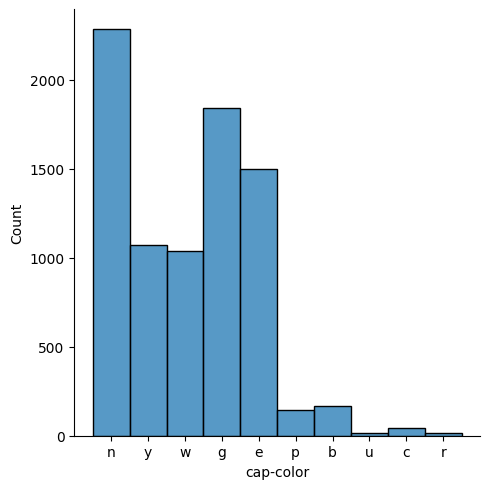

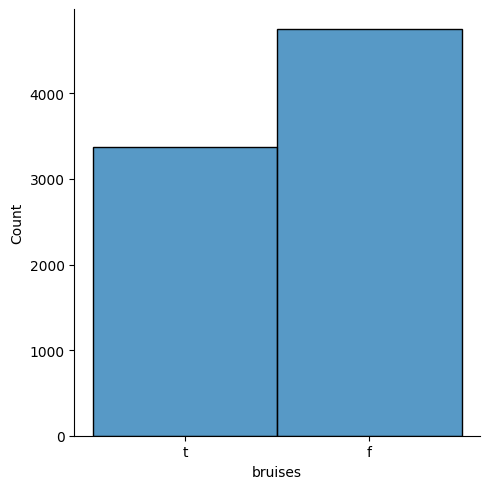

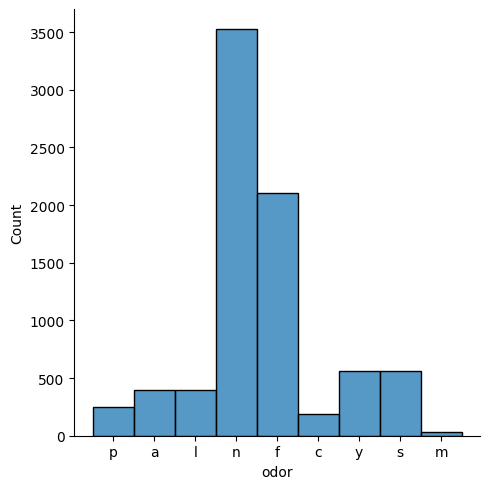

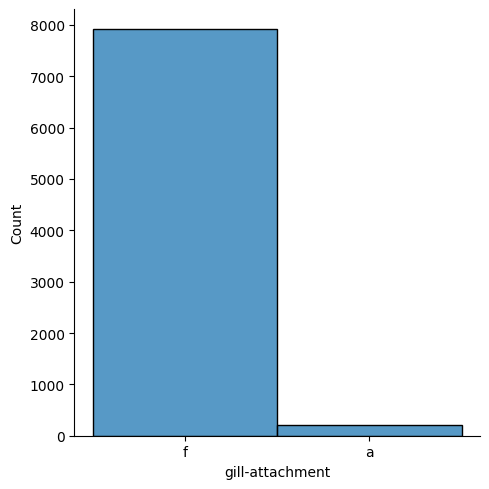

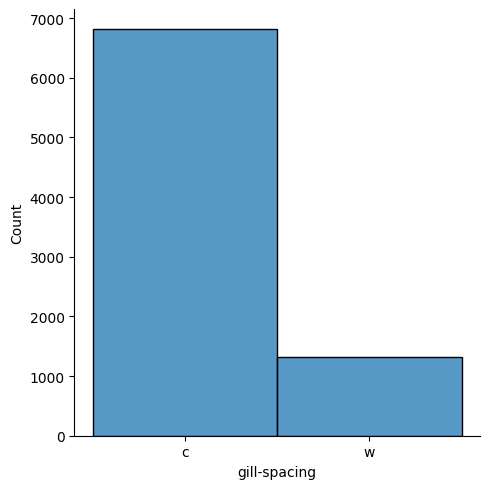

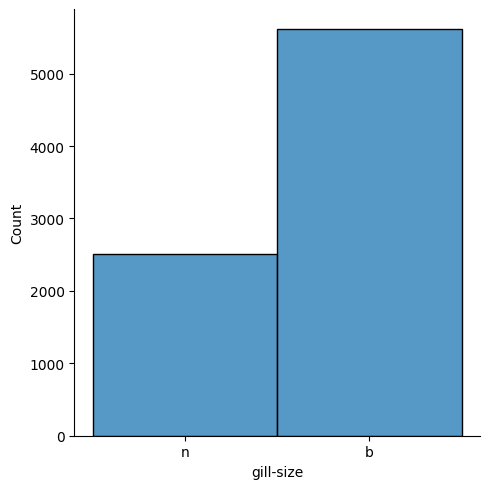

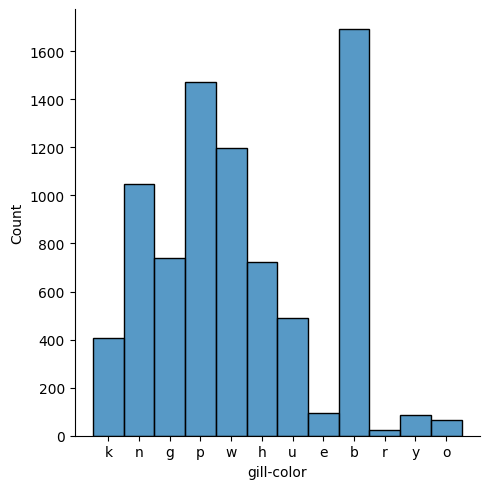

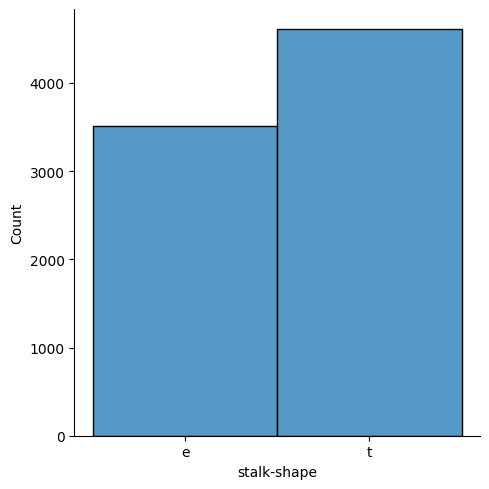

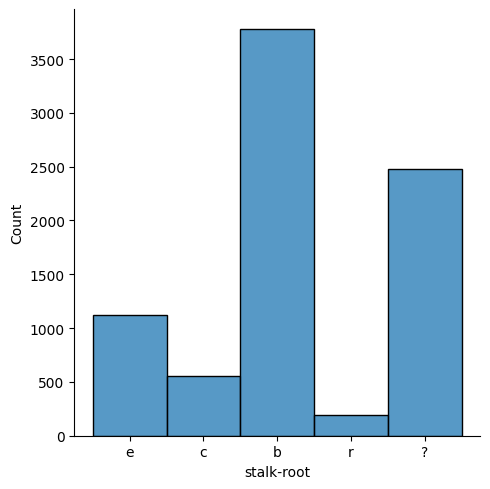

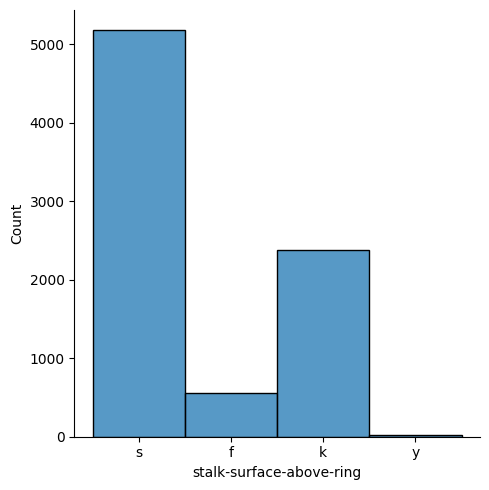

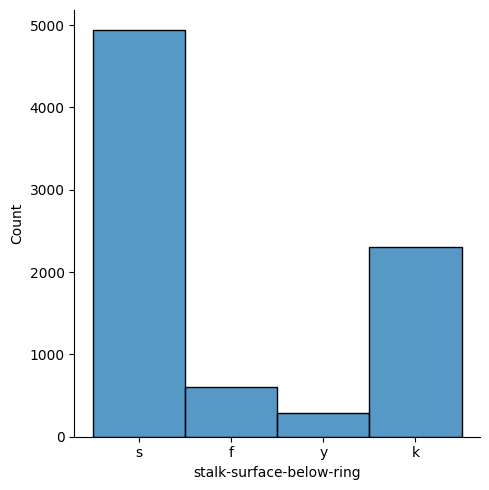

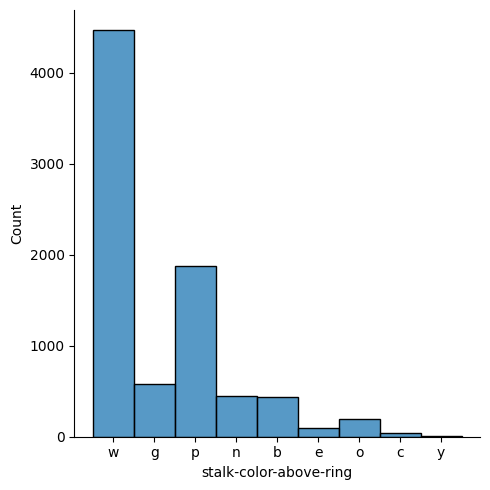

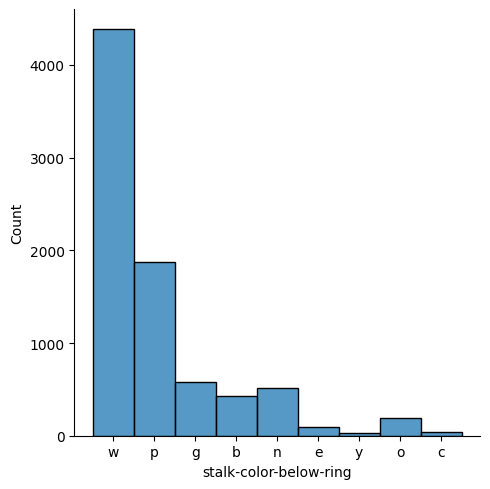

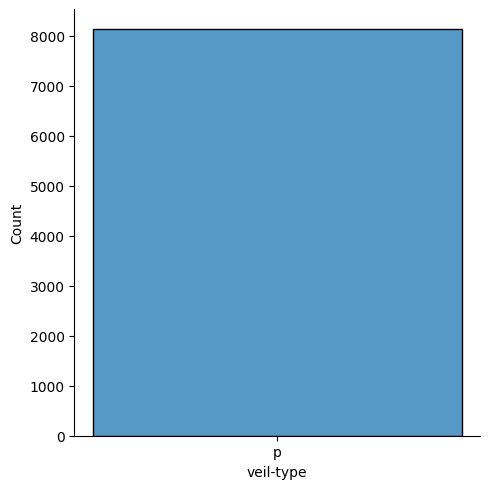

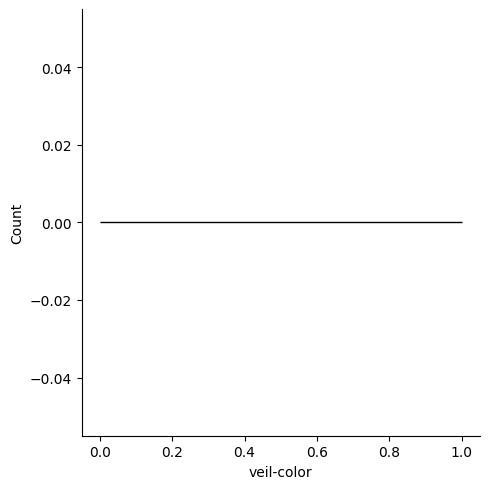

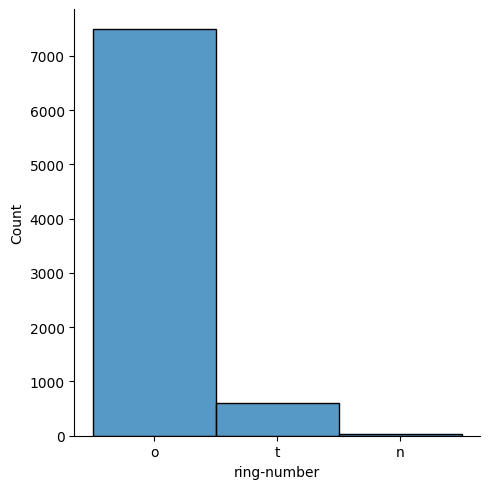

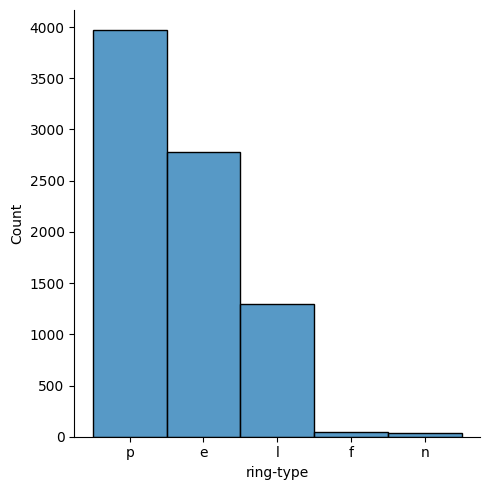

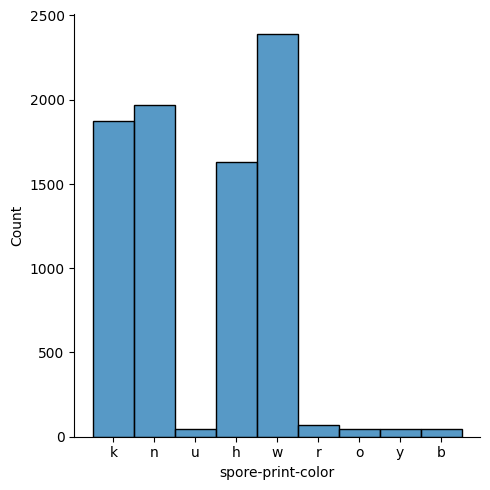

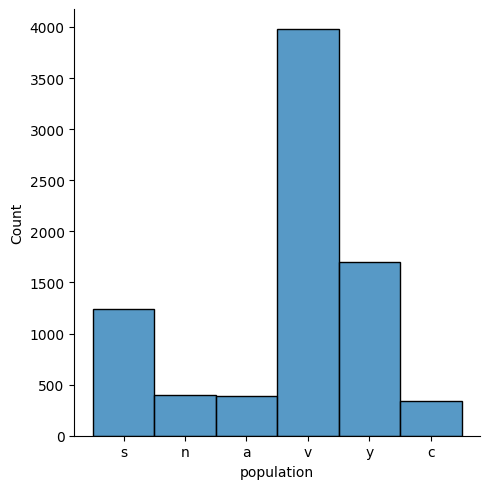

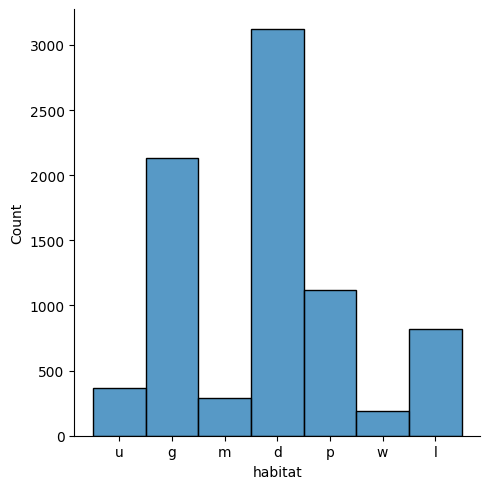

In [18]:
# (1c) Histograms of all features
for column in df.columns:
    sns.displot(df, x=column)

In [21]:
# (1c) It can be seen from both the histograms and the correlation matrix that veil-type and veil-color
# are anomalous. The veil-type feature is 'p' for all entries, and there is no data on what veil-color is
# per entry. Both these features thus contain no important information for our purposes, and we
# should remove them. Also, a significant amount of mushrooms contain the value '?' for the feature
# 'stalk-root'. Presumably, this means the stalk-root was not or could not be identified for those entries.



In [28]:
# (1d) Reload the original dataset and fix anomalies.
df = pd.read_csv('mushrooms.csv')
df = df.drop(columns=['veil-type', 'veil-color'])

# As stated above, we are missing some values in the 'stalk-root' feature. There is an identifiable pattern
# in that the first rows of the dataset contain no missing values, and the final rows contain almost only
# missing values in 'stalk-root', however I am unable to draw any conclusions from this without knowing
# more about the dataset and how observations were made. Removing the missing data entirely is not a valid
# approach, as we do not know if these values were missing at random or not. Also, a very large percentage of
# observations have missing data in that feature, so we would lose too much data. Our other two options are
# to drop the 'stalk-root' feature entirely, or to impute. I have decided to drop the feature entirely, due
# to the percentage of missing data.

df = df.drop(columns=['stalk-root'])

# Yes there are many categorical outliers, such as 'g' in 'cap-surface'. However, to be an outlier in a
# categorical feature is not equivalent to being an outlier in a numerical one.
# There is no reason to remove these entries.


<Axes: xlabel='count', ylabel='class'>

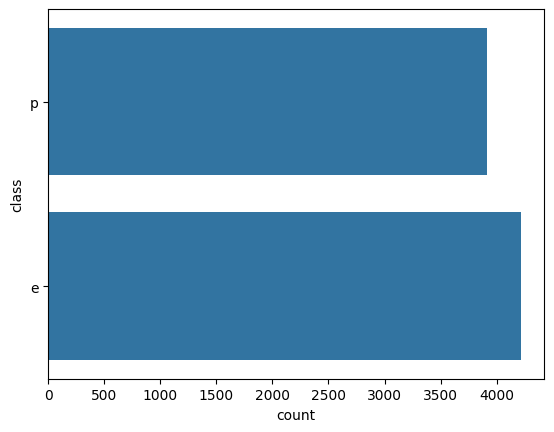

In [30]:
# (1e) This dataset is balanced with respect to the class labels.
sns.countplot(df['class'])

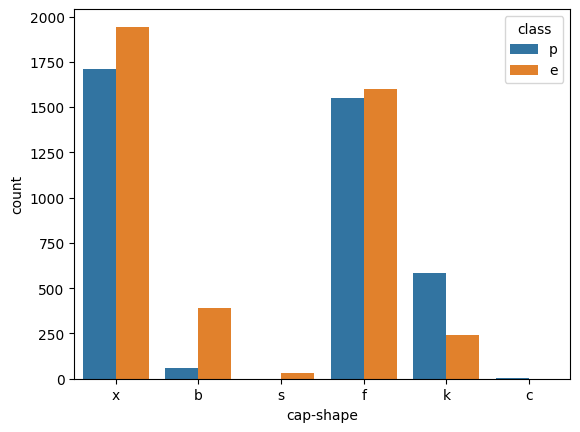

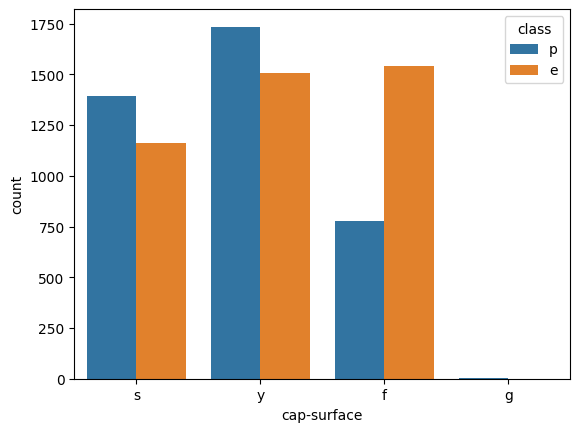

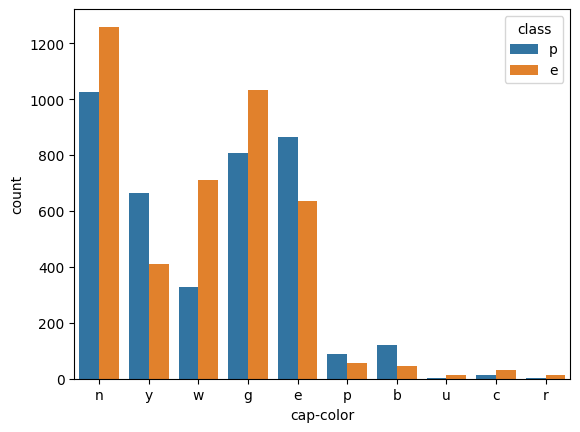

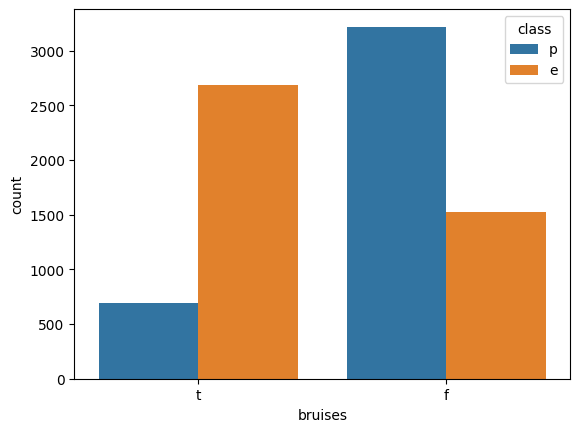

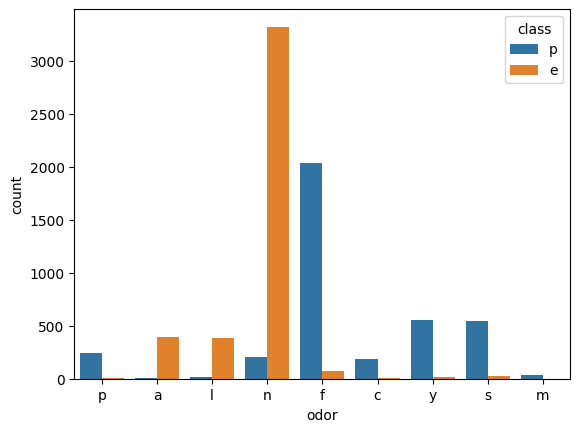

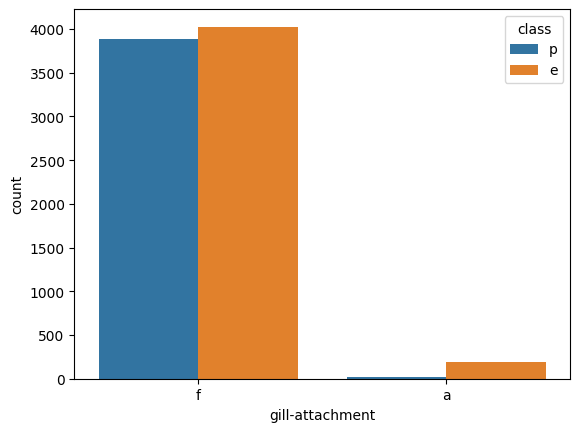

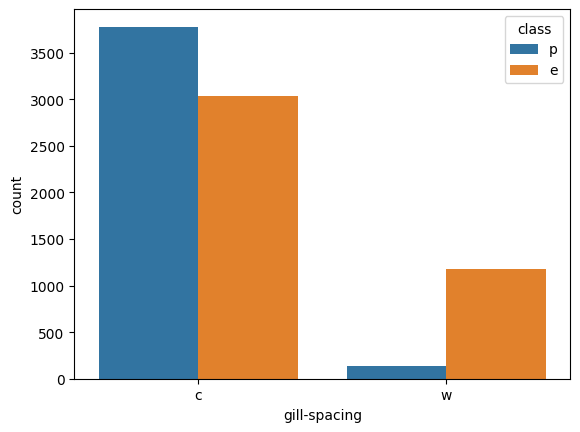

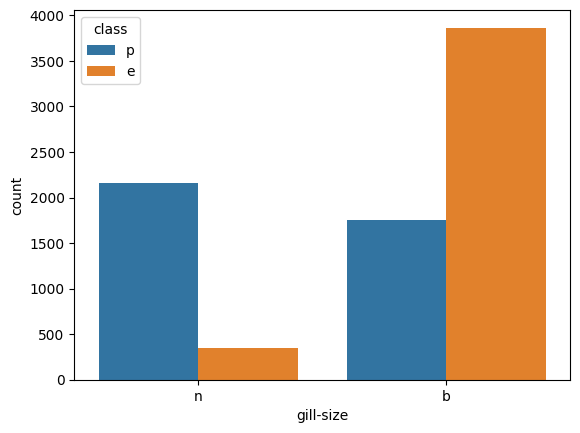

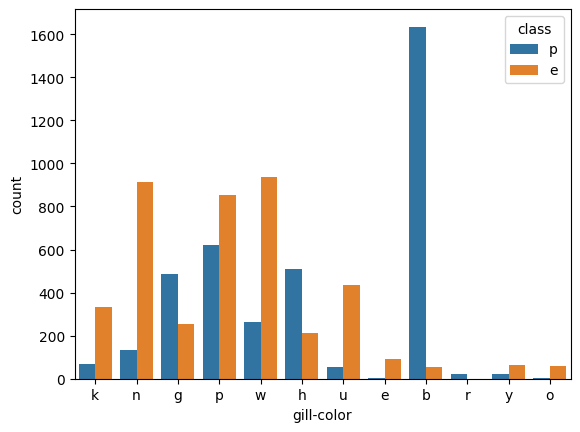

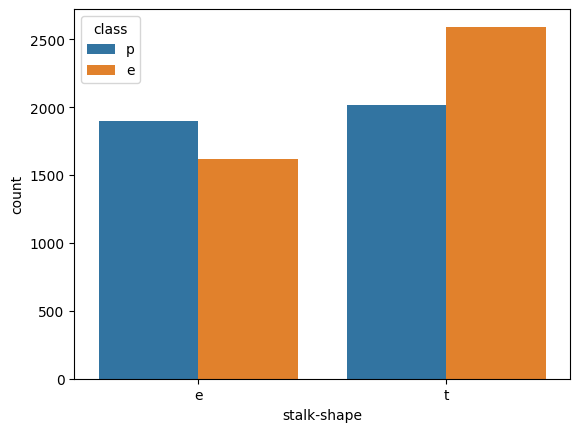

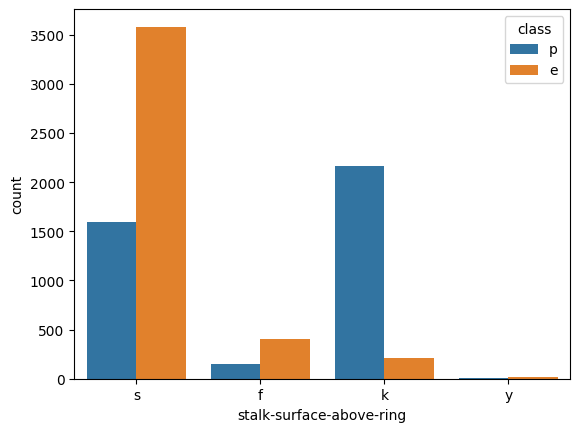

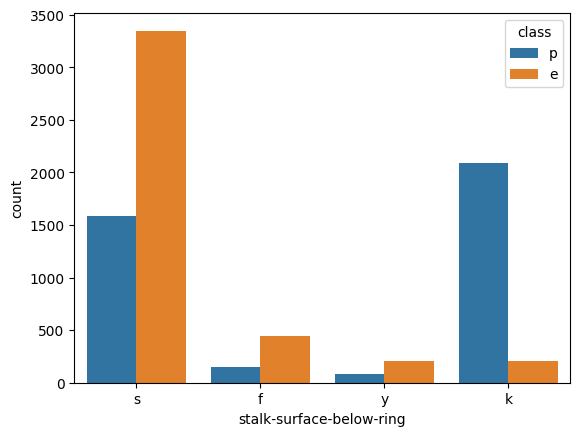

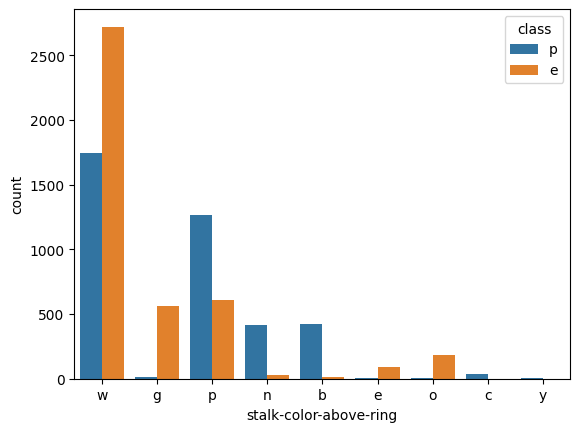

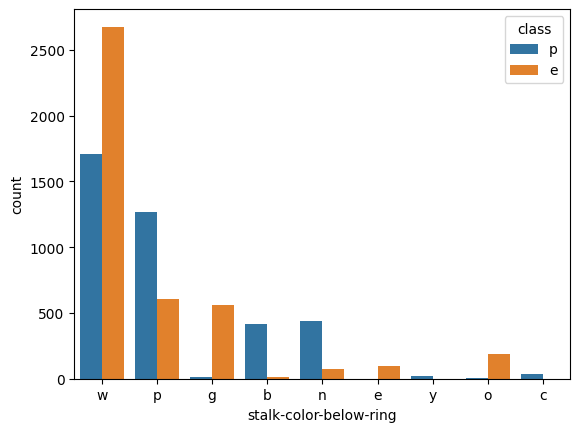

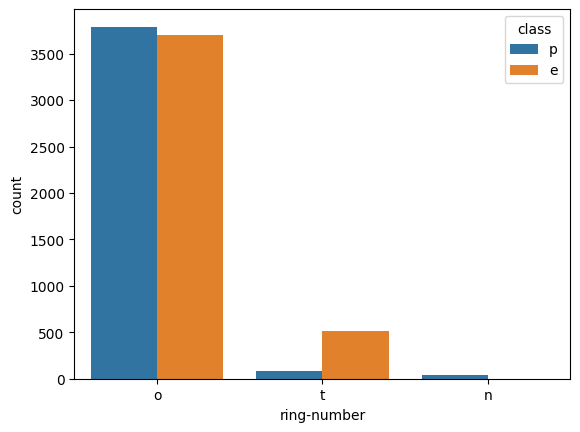

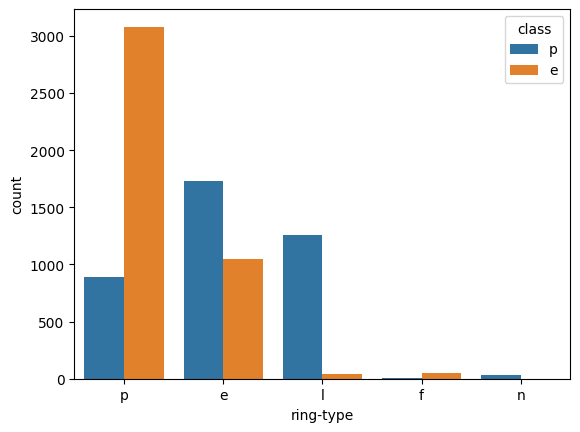

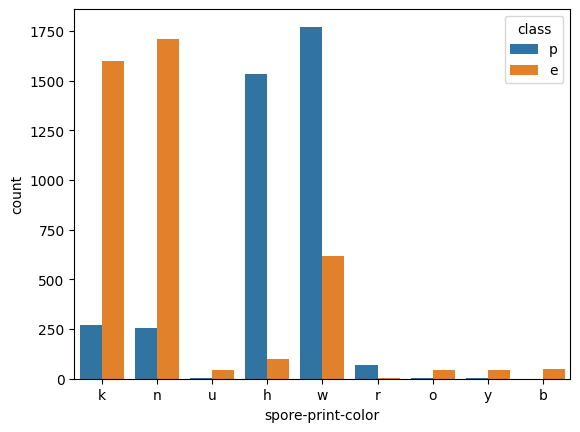

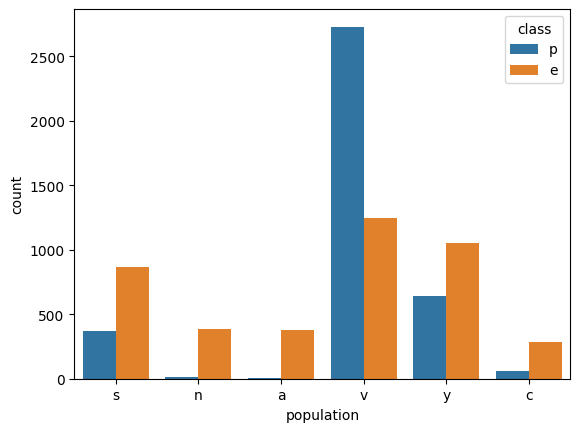

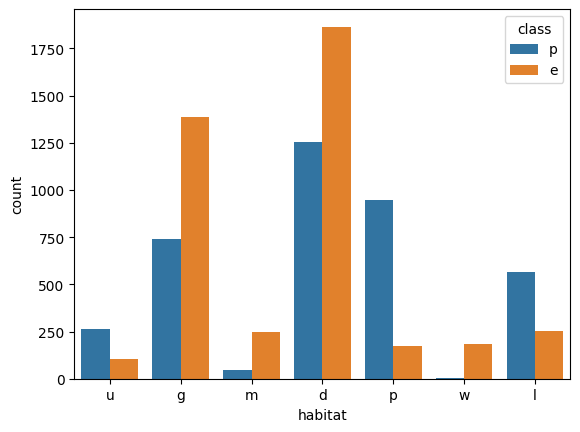

In [38]:
# (1f) Count plots showing class distribution for all features
for column in df.columns.drop("class"):
  plt.figure()
  sns.countplot(data=df, x=column, hue="class")


In [ ]:
# (1f) Of all features, 'odor' and 'spore-print-colour' seem to be the best indicators for posionous vs. edible
# mushrooms. Obvious features like 'cap-color' had very little correlation.

In [40]:
# (1g) Seperate target and feature variables.

X = df.drop(columns=["class"])
y = df["class"]

In [44]:
# (1h)

X = pd.get_dummies(X)
y = Encoder_Data.fit_transform(y)

[1 0 0 ... 0 1 0]


In [ ]:
# (1i) The Gini Index measures the probability of a particular
# variable being wrongly classified when it is randomly chosen.
# In the context of decision trees, we want to split the feature space into 'pure' classes,
# which the Gini Index is one way of measuring. A pure class would have a Gini Index of 0, so we can
# decide on feature selection by minimizing the Gini Index.

In [172]:
# (1j)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

def j(model="DecisionTreeClassifier", criterion="gini"):
  X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

  if model == "DecisionTreeClassifier":
    dt = DecisionTreeClassifier(random_state=1, criterion=criterion)
  elif model == "RandomForestClassifier":
    dt = RandomForestClassifier(random_state=1, criterion=criterion)
  dt.fit(X_train, y_train)

  predictions = dt.predict(X_test)

  print("Classification Report:")
  print(classification_report(y_test, predictions))

  print("Confusion Matrix:")
  print(confusion_matrix(y_test, predictions))

i()

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.94      1021
           1       0.94      0.93      0.93      1010

    accuracy                           0.94      2031
   macro avg       0.94      0.94      0.94      2031
weighted avg       0.94      0.94      0.94      2031

Confusion Matrix:
[[956  65]
 [ 67 943]]


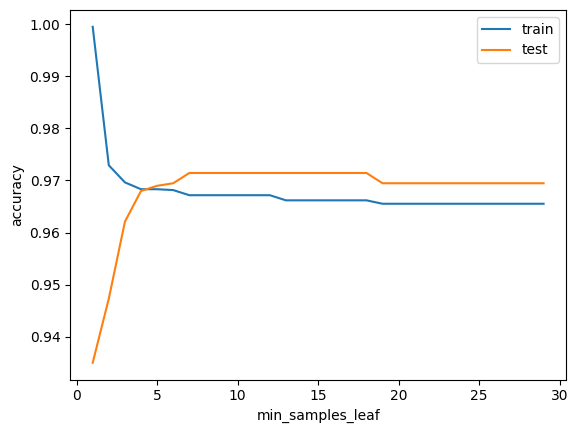

In [217]:
# (1k)
from sklearn.metrics import accuracy_score, precision_score, recall_score

def kl(model="DecisionTreeClassifier", criterion="gini", hyperparameter="min_samples_leaf", metric="accuracy"):

  df_train = pd.DataFrame(columns=[hyperparameter, metric])
  df_test = pd.DataFrame(columns=[hyperparameter, metric])
  for i in range(1, 30):
    if model == "DecisionTreeClassifier":
      if hyperparameter == "min_samples_leaf":
        dt = DecisionTreeClassifier(min_samples_leaf=i, random_state=1, criterion=criterion)
      elif hyperparameter == "max_depth":
        dt = DecisionTreeClassifier(max_depth=i, random_state=1, criterion=criterion)
    elif model == "RandomForestClassifier":
      if hyperparameter == "n_estimators":
        dt = RandomForestClassifier(n_estimators=i, random_state=1, criterion=criterion)
      elif hyperparameter == "max_depth":
        dt = RandomForestClassifier(max_depth=i, random_state=1, criterion=criterion)
    dt.fit(X_train, y_train)

    if metric == "accuracy":
      metric_train = accuracy_score(y_train, dt.predict(X_train))
      metric_test = accuracy_score(y_test, dt.predict(X_test))
    elif metric == "precision":
      metric_train = precision_score(y_train, dt.predict(X_train))
      metric_test = precision_score(y_test, dt.predict(X_test))
    elif metric == "recall":
      metric_train = recall_score(y_train, dt.predict(X_train))
      metric_test = recall_score(y_test, dt.predict(X_test))
    df_train.loc[len(df_train)] = [i, metric_train]
    df_test.loc[len(df_test)] = [i, metric_test]



  sns.lineplot(data=df_train, x=hyperparameter, y=metric, label="train")
  sns.lineplot(data=df_test, x=hyperparameter, y=metric, label="test")
  plt.show()

kl()

In [ ]:
# (1k) As expected, a very small amount of samples per leaf allows the training set to reach 100% accuracy
# when tested on itself, as it can just memorize its training data. On the test set, however, a min_samples_leaf
# from around 8-18 results in the most accurate model. The accuracies are negatively correlated when
# testing on the train or test data; as one rises the other falls.

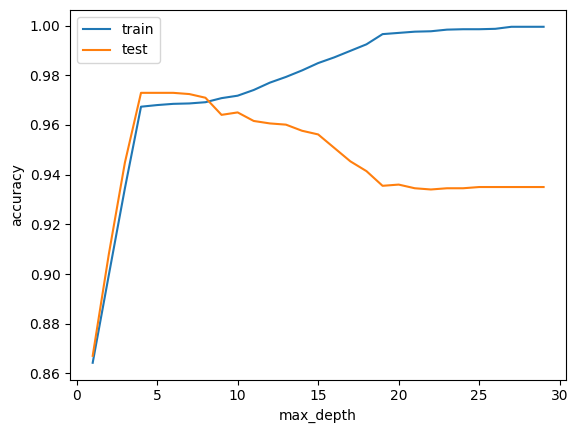

In [184]:
# (1l)

kl(hyperparameter="max_depth")

In [ ]:
# (1l) Here maximum tree depth improves the models performance on the training set, again because it allows
# for better memorization, however the ideal max_depth for the model is 4, as that is where the model
# performs best on the test set.

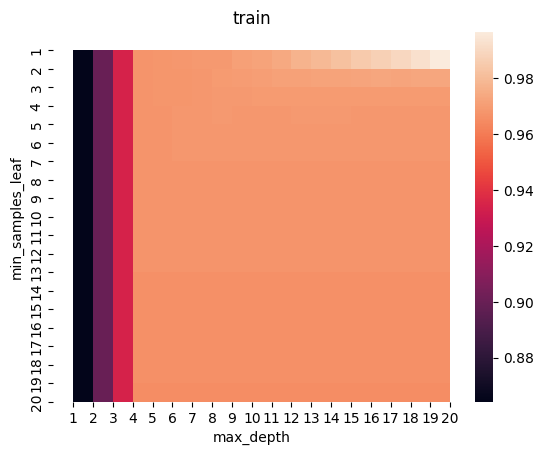

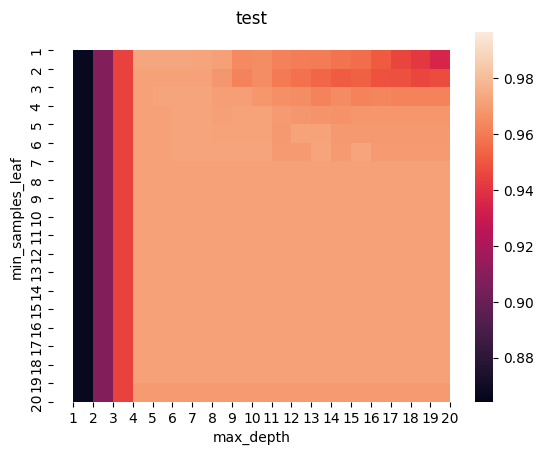

In [187]:
# (1m)

def m(model="DecisionTreeClassifier", criterion="gini"):
  df_train = pd.DataFrame(np.nan, index=range(20), columns=range(20))
  df_test = pd.DataFrame(np.nan, index=range(20), columns=range(20))

  for i in range(1, 20):
    for j in range(1, 20):
      if model == "DecisionTreeClassifier":
        dt = DecisionTreeClassifier(min_samples_leaf=i, max_depth=j, random_state=1, criterion=criterion)
      elif model == "RandomForestClassifier":
        dt = RandomForestClassifier(n_estimators=i, max_depth=j, random_state=1, criterion=criterion)
      dt.fit(X_train, y_train)

      df_train.iloc[i, j] = accuracy_score(y_train, dt.predict(X_train))
      df_test.iloc[i, j] = accuracy_score(y_test, dt.predict(X_test))


  vmin = min(df_train.min().min(), df_test.min().min())
  vmax = max(df_train.max().max(), df_test.max().max())
  sns.heatmap(data=df_train, vmin=vmin, vmax=vmax)
  plt.title("train")
  plt.xlabel("max_depth")
  if model == "DecisionTreeClassifier":
    plt.ylabel("min_samples_leaf")
  elif model == "RandomForestClassifier":
    plt.ylabel("n_estimators")
  plt.xticks(ticks=np.arange(1, 21), labels=np.arange(1, 21))
  plt.yticks(ticks=np.arange(1, 21), labels=np.arange(1, 21))
  plt.figure()
  sns.heatmap(data=df_test, vmin=vmin, vmax=vmax)
  plt.title("test")
  plt.xlabel("max_depth")
  if model == "DecisionTreeClassifier":
    plt.ylabel("min_samples_leaf")
  elif model == "RandomForestClassifier":
    plt.ylabel("n_estimators")
  plt.xticks(ticks=np.arange(1, 21), labels=np.arange(1, 21))
  plt.yticks(ticks=np.arange(1, 21), labels=np.arange(1, 21))

m()

In [ ]:
# (1m) Our highest accuracy on the training data is when min_samples_leaf = 1 and
# max_depth = 20. On the test data, min_samples_leaf is around 6 and max_depth is around 7.
# Suitables choices then for our final model are min_samples_leaf=6 and max_depth=7.

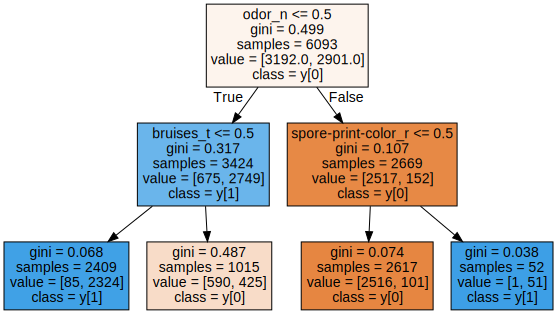

In [189]:
# (1n)
from sklearn import tree
import graphviz

dt = DecisionTreeClassifier(max_depth=2, random_state=1)
dt.fit(X_train, y_train)

# Visualize the tree
dot_data = tree.export_graphviz(
    dt,
    out_file=None,            # return as string
    feature_names=X.columns,
    class_names=True,         # for classification; use None for regression
    filled=True,              # color nodes by class/value

)

graph = graphviz.Source(dot_data)
graph.render("decision_tree_limited_depth", view=True)
graph


In [ ]:
# (1n) From this tree, we find odor is the most important feature for
# class prediction, as it is the first one we split on, followed by spore-print-color and bruises_t.
# We can infer importance as when the decision tree is so limited, information gain per split
# is paramount.


Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      1021
           1       0.93      0.93      0.93      1010

    accuracy                           0.93      2031
   macro avg       0.93      0.93      0.93      2031
weighted avg       0.93      0.93      0.93      2031

Confusion Matrix:
[[949  72]
 [ 67 943]]


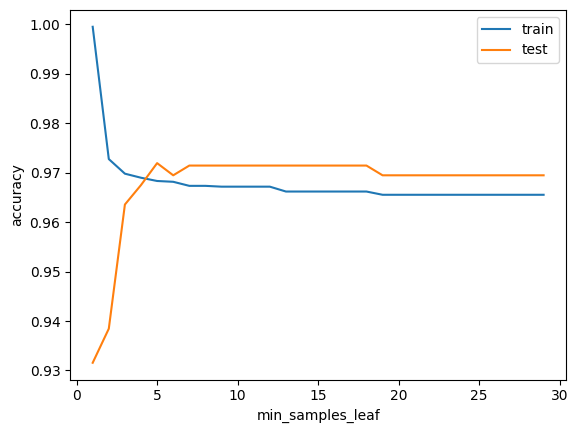

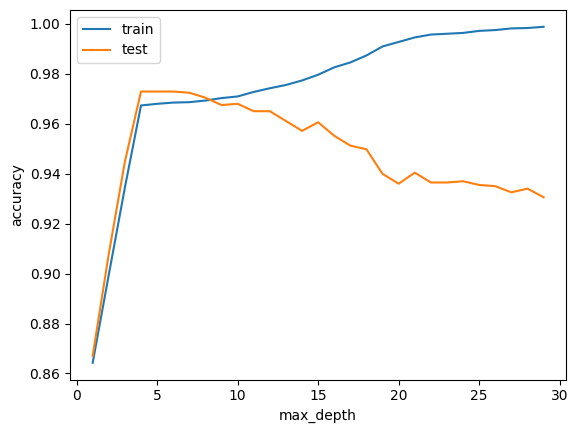

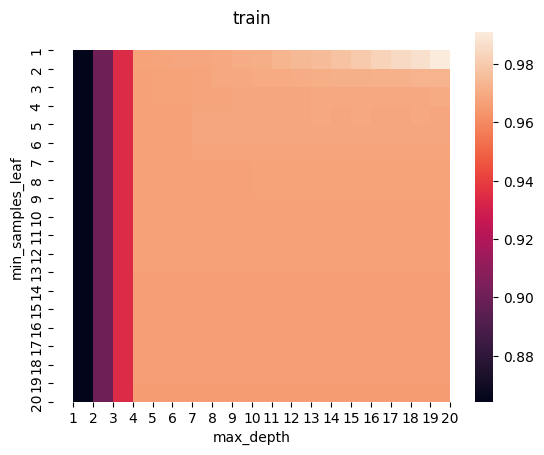

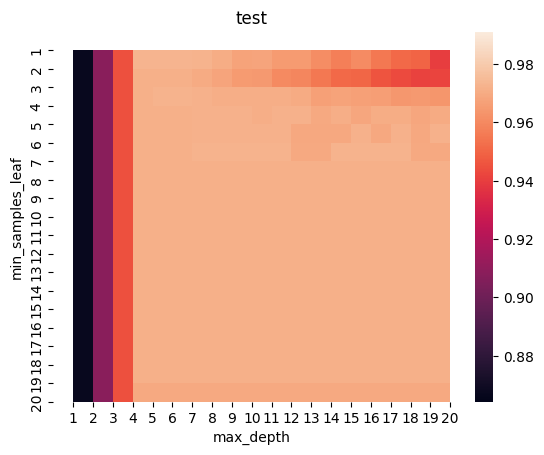

In [179]:
# (1o)

# (i) Entropy is a measure of disorder. A pure class has no entropy.

j(criterion="entropy")
kl(criterion="entropy")
kl(criterion="entropy", hyperparameter="max_depth")
m(criterion="entropy")

# Performance was not meaningfully effected by the change in decision tree criterion.

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97      1021
           1       0.97      0.98      0.97      1010

    accuracy                           0.97      2031
   macro avg       0.97      0.97      0.97      2031
weighted avg       0.97      0.97      0.97      2031

Confusion Matrix:
[[994  27]
 [ 25 985]]


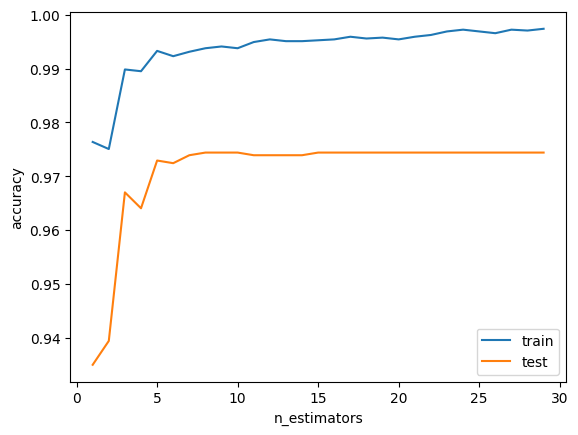

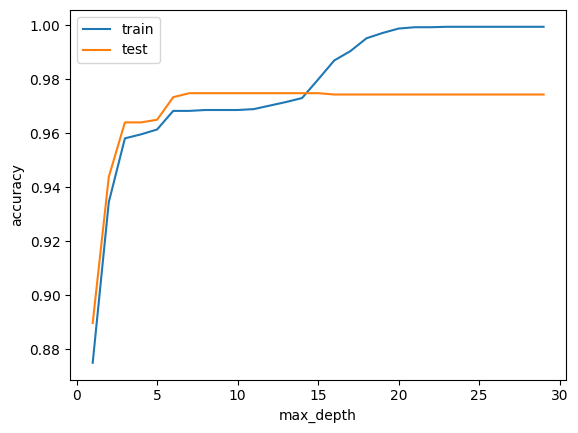

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97      1021
           1       0.97      0.98      0.97      1010

    accuracy                           0.97      2031
   macro avg       0.97      0.97      0.97      2031
weighted avg       0.97      0.97      0.97      2031

Confusion Matrix:
[[994  27]
 [ 25 985]]


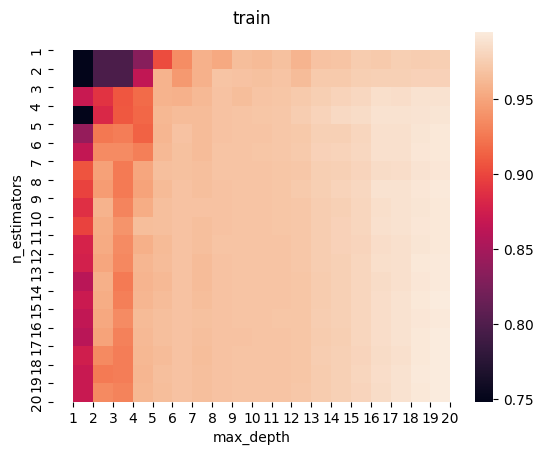

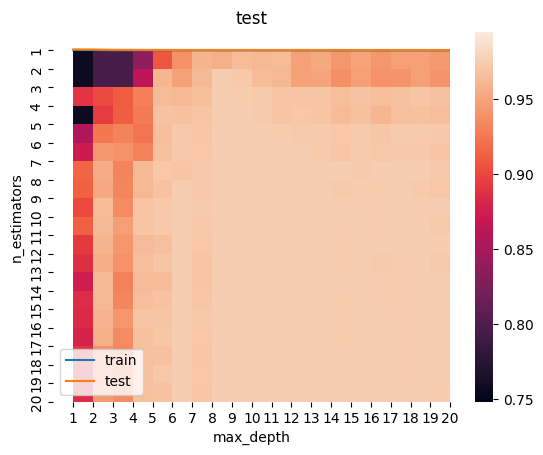

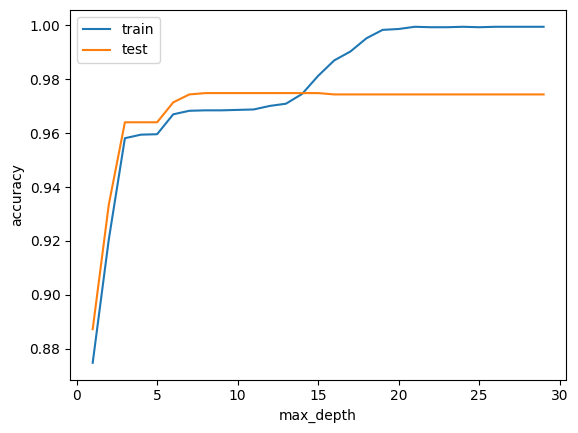

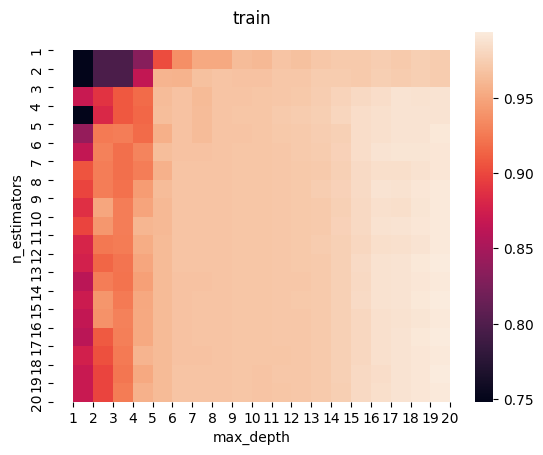

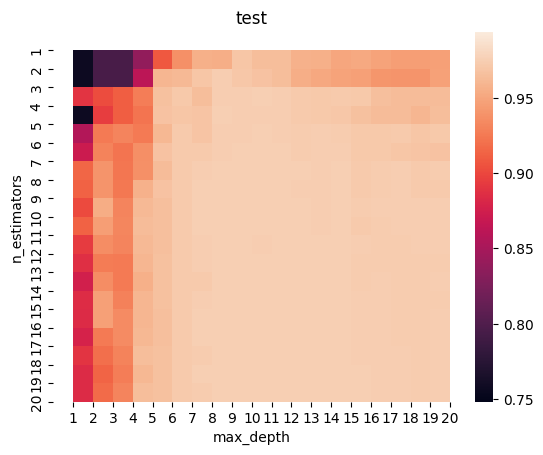

In [188]:
# (1p) Random Forest Classifier now

# (i) As could be guessed from the name, random forest classifers use multiple decision trees, so the criterions
# function the same.

j(model="RandomForestClassifier")
kl(model="RandomForestClassifier", hyperparameter="n_estimators")
kl(model="RandomForestClassifier", hyperparameter="max_depth")
m(model="RandomForestClassifier")

j(model="RandomForestClassifier", criterion='entropy')
kl(model="RandomForestClassifier", criterion='entropy', hyperparameter="n_estimators")
kl(model="RandomForestClassifier", criterion='entropy', hyperparameter="max_depth")
m(model="RandomForestClassifier", criterion='entropy')



In [ ]:
# (1p) The RandomForestClassifer does not seem to be a significant upgrade from the DecisionTreeClassifer,
# though it is more forgiving in terms of the hyperparameters you can use. Both models ended up with peak
# accuracies just below 98%. n_estimators of above around is 4 ideal for the random forest classifer,
# and a max depth of above 8 as well. Again we see in the max_depth chart when memorization begins,
# at a max_depth of about 18, at which point our classifer reaches 100% accuracy.
# Entropy vs Gini criteria again do not change the performance significantly.

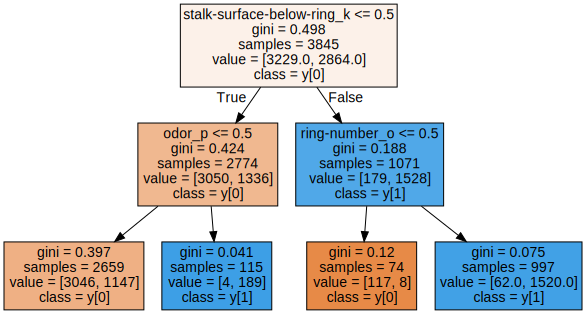

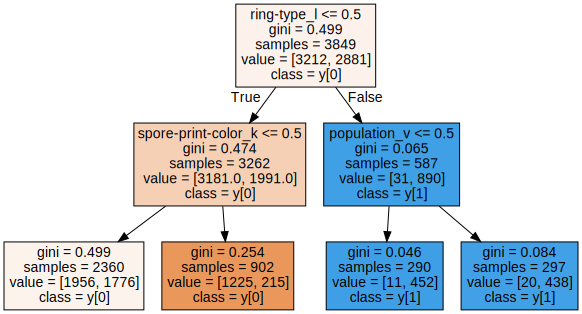

In [205]:
# (1q)
dt = RandomForestClassifier(max_depth=2, n_estimators=2, random_state=1)
dt.fit(X_train, y_train)

for estimator in dt.estimators_:
  dot_data = tree.export_graphviz(
      estimator,
      out_file=None,
      feature_names=X.columns,
      class_names=True,
      filled=True,

  )
  graph = graphviz.Source(dot_data)
  graph.render("decision_tree_limited_depth", view=True)
  display(graph)



In [200]:
# (1q)
# The feature importance is more balanced in the random forest classifier, due to multiple trees, but still
# odor, spore-print-color show up as important features. The most important features, taking into account both runs,
# do align with what I initially predicted based on the histograms. However the randomness introduced by the
# random tree classifer lead to some unpredicted features.

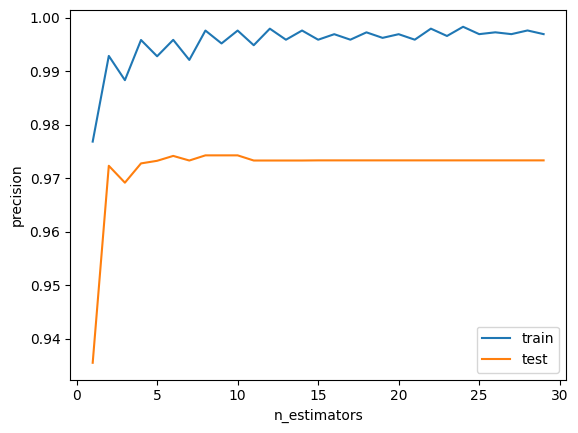

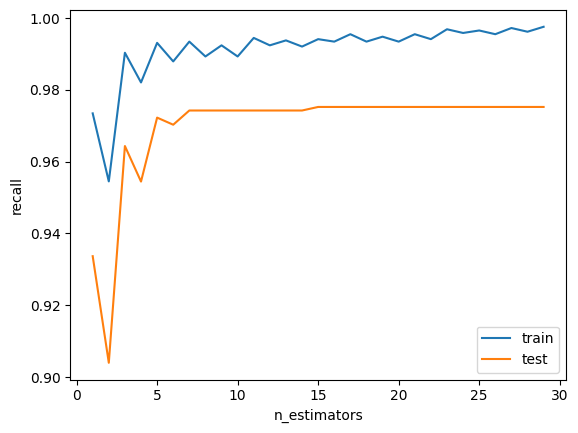

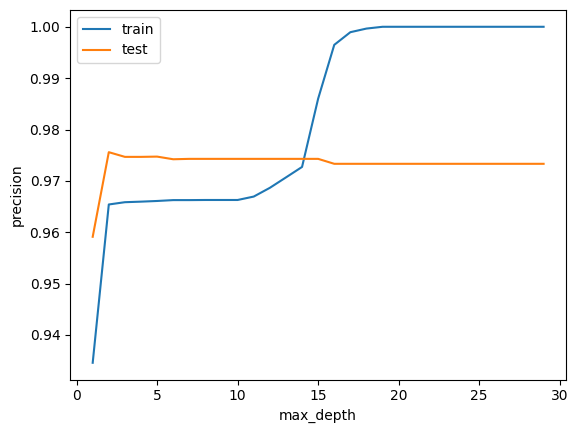

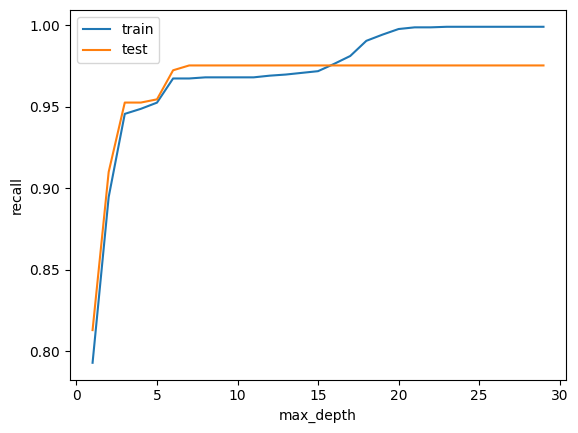

In [219]:
# (1r) As n_estimators increases, precision and recall increase sharply at first, then even out at values
# around 5. However, precision slightly falls and recall slightly rises As max_depth increases, precision rises
# quickly then slowly decreases while recall rises quickly
# then stays high. You may, when choosing your n_estimators hyperparameter, have to make a slight tradeoff
# between precision and recall.

kl(model="RandomForestClassifier", hyperparameter="n_estimators", metric="precision")
kl(model="RandomForestClassifier", hyperparameter="n_estimators", metric="recall")
kl(model="RandomForestClassifier", hyperparameter="max_depth", metric="precision")
kl(model="RandomForestClassifier", hyperparameter="max_depth", metric="recall")

In [ ]:
# (1s)